---
# **Proyek Akhir: Menyelesaikan Permasalahan Perusahaan "Jaya Jaya Maju"**
---

- Nama: Muhammad Pangeran Nabil
- Email: mpnabil95@gmail.com
- Id Dicoding: pangeran_nabil

## **A. Business Understanding**

Tahap ini adalah fondasi dari proyek. Kita mendefinisikan masalah spesifik (tingginya dropout) dan menetapkan tujuan yang terukur. Dengan memahami 'mengapa' kita melakukan analisis ini, kita dapat memastikan bahwa model yang dibangun benar-benar menjawab kebutuhan institusi.


Jaya Jaya Institut menghadapi permasalahan tingginya jumlah mahasiswa yang tidak menyelesaikan pendidikan atau dropout.
Institusi ingin mendeteksi mahasiswa yang berisiko dropout sedini mungkin agar dapat diberikan intervensi yang tepat.

 Problem Statements:
1. Faktor apa saja yang paling berkaitan dengan status akhir mahasiswa?
2. Bagaimana membangun model machine learning untuk memprediksi status mahasiswa?
3. Bagaimana membantu pihak institusi memonitor performa siswa melalui dashboard?

Goals:
1. Mengidentifikasi faktor-faktor yang berkaitan dengan dropout.
2. Membangun model klasifikasi untuk memprediksi status mahasiswa.
3. Menyediakan dashboard dan prototype machine learning yang mudah digunakan.

Solution Statements:
1. Melakukan analisis data eksploratif untuk menemukan pola utama.
2. Membangun beberapa model klasifikasi multiclass.
3. Memilih model terbaik berdasarkan metrik evaluasi yang relevan.
4. Membuat dashboard Metabase dan prototype Streamlit.

## **B. Gathering Data**

### Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import joblib

### Load Data

In [3]:
url = "https://raw.githubusercontent.com/mpnabil95/Students-Performance/main/data.csv"
df = pd.read_csv(url, sep=';')

## **C. Data Understanding**

Pada tahap ini, kita melakukan 'inspeksi' awal terhadap dataset. Kita memeriksa apakah ada data yang kosong (missing values) atau duplikat yang bisa merusak akurasi model nantinya. Berdasarkan pengecekan, dataset ini berkualitas tinggi karena tidak memiliki nilai kosong.

### Mengecek Bentuk Data


In [4]:
display(df.head())

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### **Interpretasi Awal Data**

Berdasarkan tampilan data di atas, kita dapat melihat bahwa dataset mengandung berbagai fitur yang mencakup profil demografis (status pernikahan, kebangsaan), jalur masuk (mode aplikasi, urutan aplikasi), latar belakang sosial ekonomi (pekerjaan dan kualifikasi orang tua), serta performa akademik mahasiswa pada semester 1 dan 2. Variabel target kita adalah `Status` yang akan membedakan mahasiswa menjadi tiga kategori: Dropout, Enrolled, atau Graduate.

In [5]:
print("Shape:", df.shape)

Shape: (4424, 37)


### Mengecek tipe data, jumlah baris, dan mendeteksi missing values


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [7]:
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))


Missing values:
Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                

### Mengecek jumlah nilai duplikat


In [8]:
print("\nJumlah Data Duplikat:")
print(df.duplicated().sum())


Jumlah Data Duplikat:
0


### Mengecek Distribusi Target

In [9]:
print(df['Status'].value_counts())

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


Dataset terdiri dari 4424 baris dan 37 kolom. Target prediksi adalah Status yang terdiri dari:
- Dropout
- Enrolled
- Graduate

Secara umum dataset sudah cukup bersih karena tidak ditemukan missing value.

## **D. Exploratory Data Analyst (EDA)**

EDA adalah proses detektif data. Di sini kita mencari pola:
- **Faktor Finansial**: Apakah mahasiswa yang menunggak biaya kuliah cenderung dropout?
- **Performa Akademik**: Seberapa besar pengaruh nilai semester 1 terhadap keberhasilan di semester 2?
- **Demografi**: Apakah umur saat mendaftar mempengaruhi ketahanan mahasiswa?

### **Analisis Distribusi Target**

Grafik di bawah ini menunjukkan keseimbangan kelas pada data kita. Terlihat bahwa jumlah mahasiswa yang lulus (*Graduate*) adalah mayoritas, namun jumlah *Dropout* yang mencapai lebih dari 1.400 siswa (sekitar 32%) merupakan angka yang signifikan. Hal ini mengonfirmasi urgensi bagi Jaya Jaya Institut untuk memiliki sistem prediksi dini.

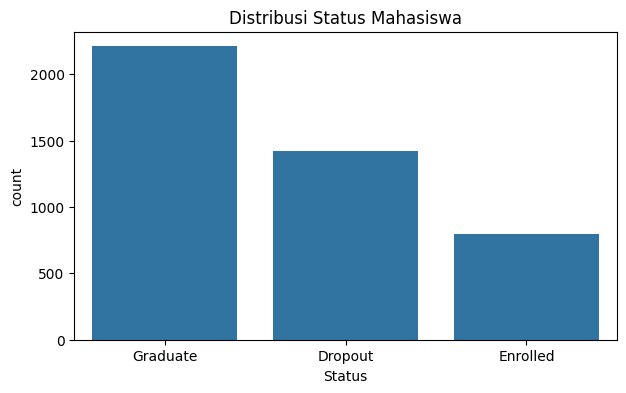

In [10]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Status', order=df['Status'].value_counts().index)
plt.title('Distribusi Status Mahasiswa')
plt.show()

### Statistik Numerik


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


### **Analisis Korelasi Antar Fitur**

Heatmap korelasi menunjukkan hubungan linear antar variabel numerik.
- Kita melihat korelasi yang sangat kuat (di atas 0.90) antara unit yang diambil (*enrolled*) dan unit yang disetujui (*approved*) pada semester yang sama.
- Terdapat juga korelasi positif yang kuat antara performa semester 1 dan semester 2, menunjukkan bahwa mahasiswa yang berprestasi di awal cenderung mempertahankan performanya.

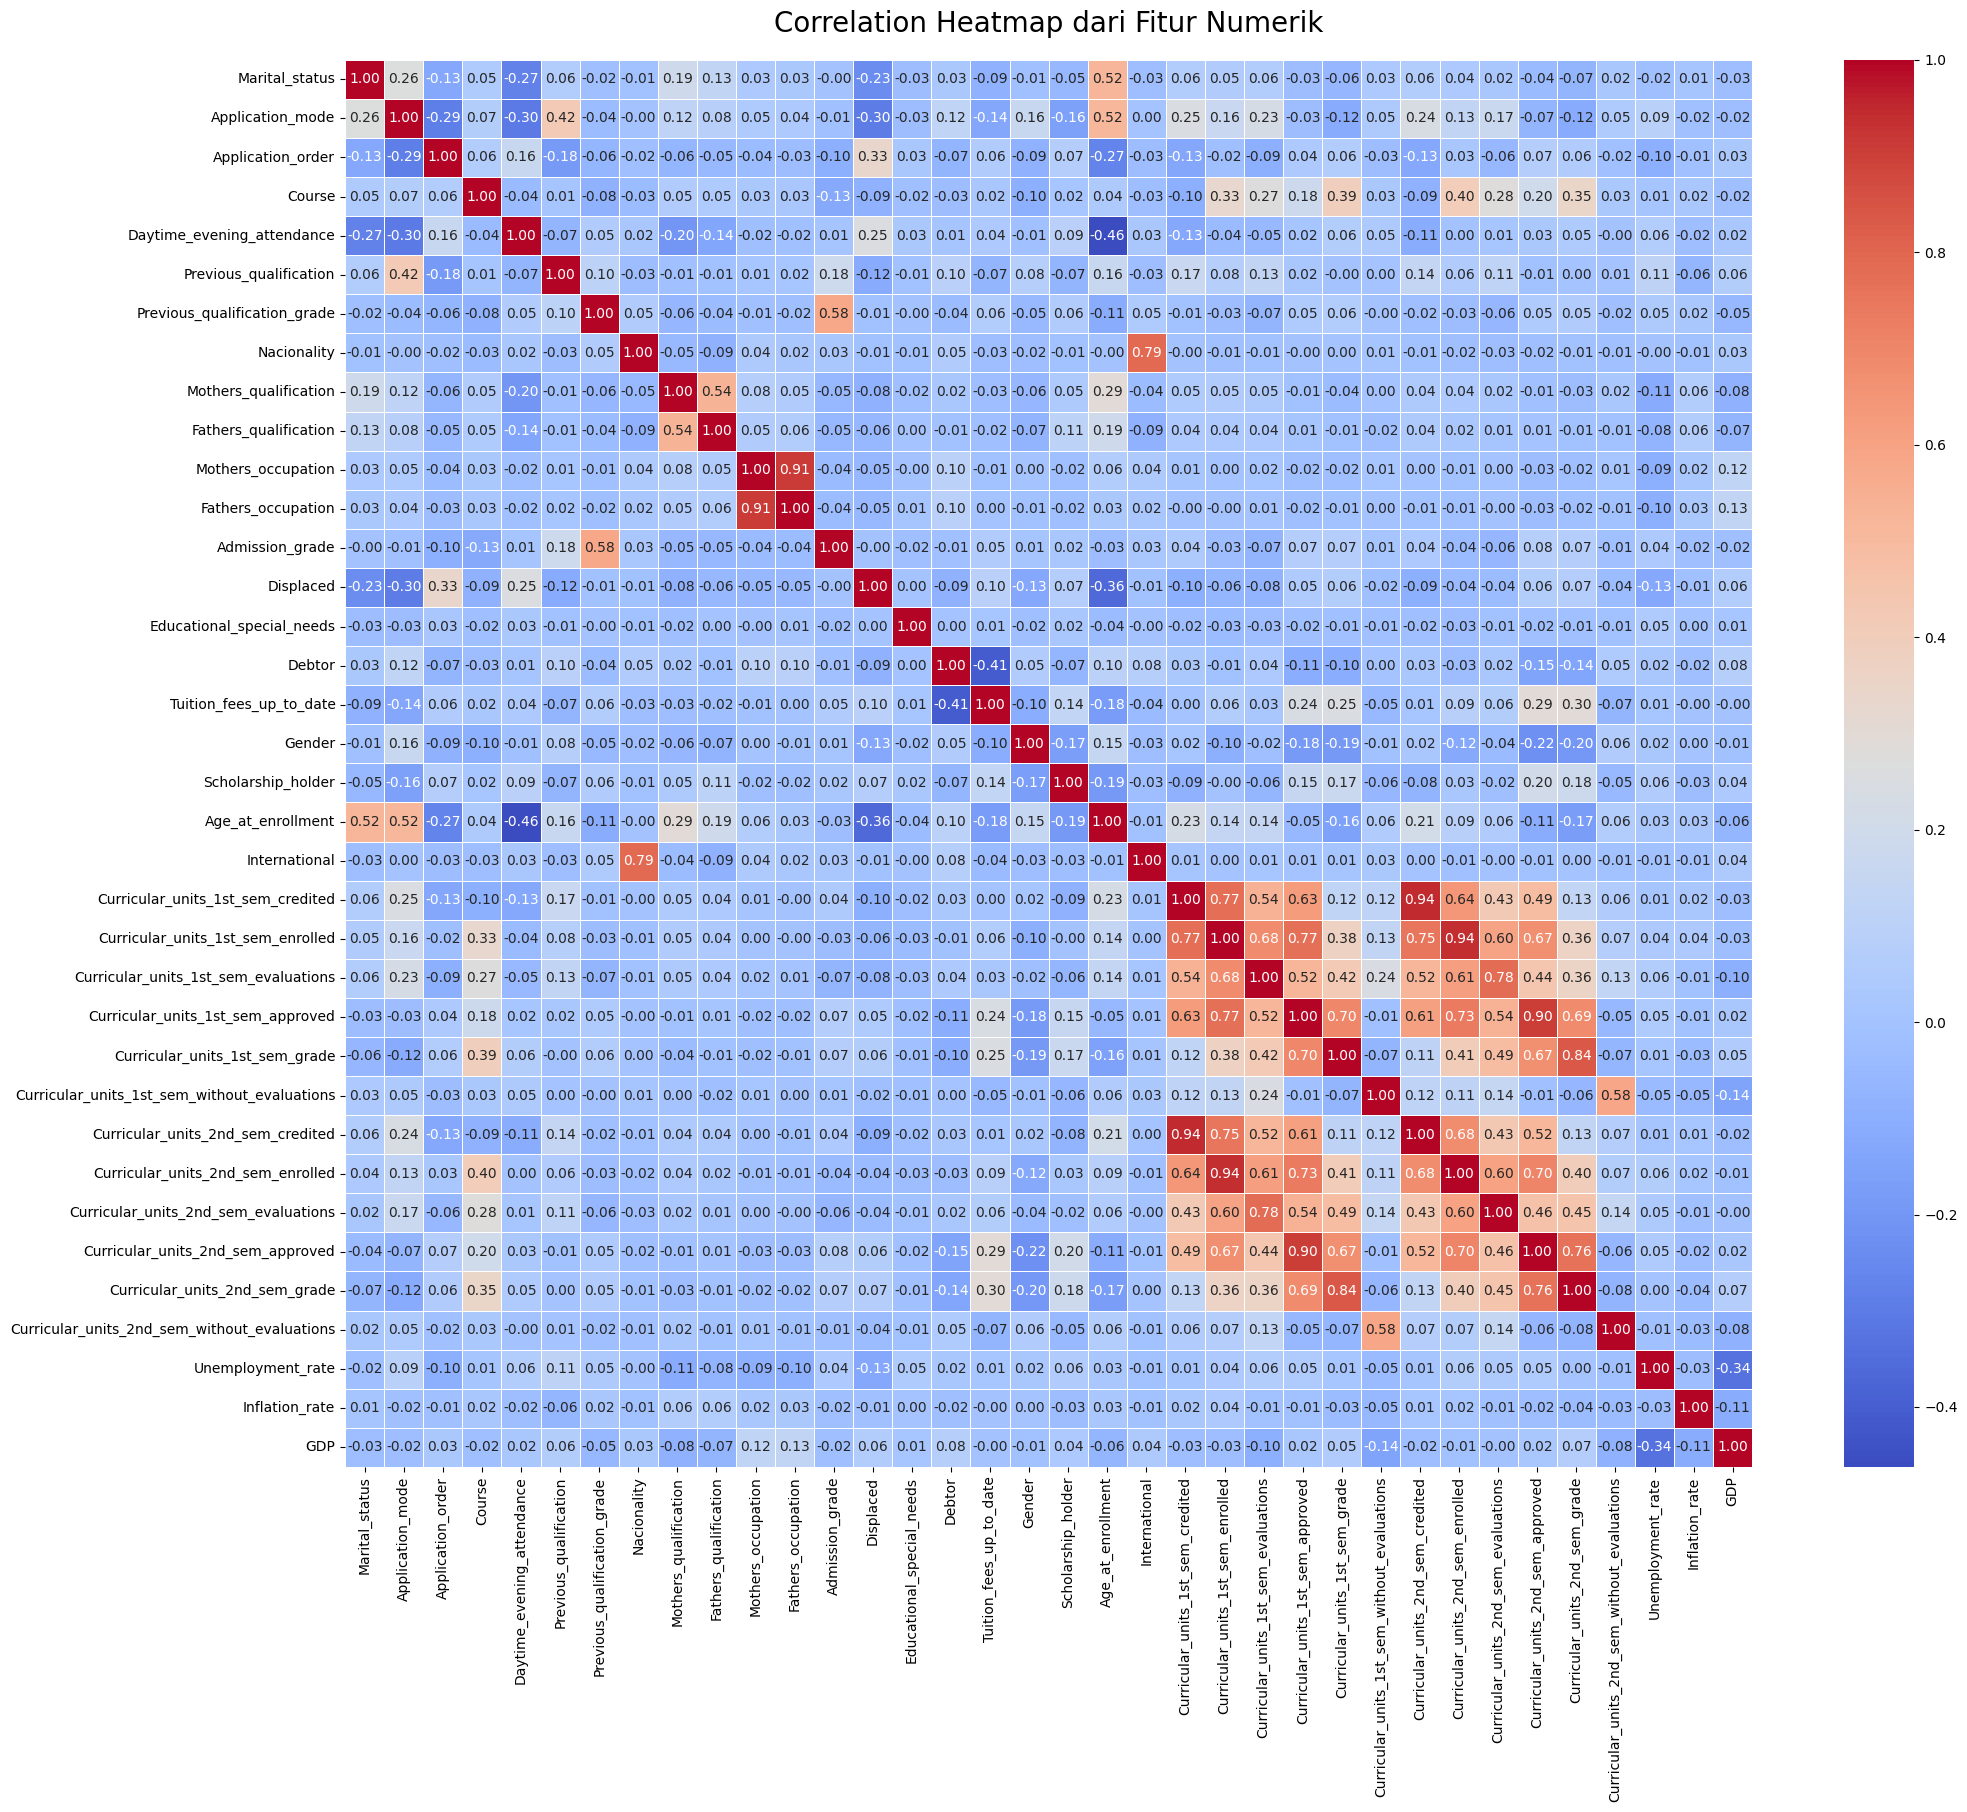

In [12]:
kolom_numerik = df.select_dtypes(include=['int64', 'float64'])

matriks_korelasi = kolom_numerik.corr()

plt.figure(figsize=(22, 18))
sns.heatmap(matriks_korelasi,
            annot=True,       # Menampilkan angka korelasi
            fmt=".2f",        # Format 2 angka di belakang koma
            cmap="coolwarm",  # Skema warna: merah (korelasi positif), biru (korelasi negatif)
            cbar=True,
            square=True,
            linewidths=.5)

plt.title('Correlation Heatmap dari Fitur Numerik', fontsize=20, pad=20)
plt.tight_layout()
plt.show()

### **Interpretasi Faktor Finansial**

Visualisasi di bawah membandingkan status mahasiswa dengan kondisi keuangan mereka:
1. **Tuition Fees Up To Date**: Mahasiswa yang menunggak biaya kuliah memiliki proporsi *Dropout* yang sangat tinggi dibandingkan mereka yang pembayarannya lancar.
2. **Debtor**: Mahasiswa yang tercatat sebagai debitur (berhutang) cenderung lebih berisiko *Dropout*.
3. **Scholarship Holder**: Penerima beasiswa memiliki tingkat kelulusan yang sangat dominan, menunjukkan bahwa dukungan finansial sangat efektif dalam mencegah mahasiswa berhenti kuliah.

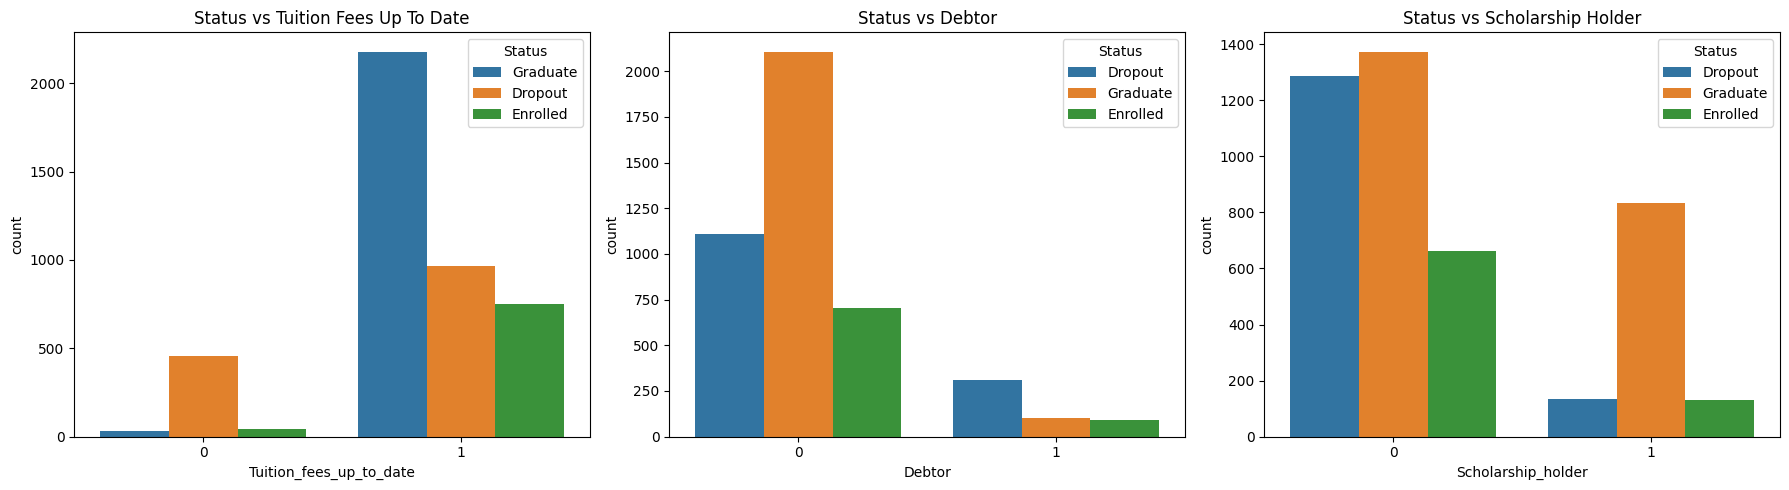

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='Tuition_fees_up_to_date', hue='Status', ax=axes[0])
axes[0].set_title('Status vs Tuition Fees Up To Date')

sns.countplot(data=df, x='Debtor', hue='Status', ax=axes[1])
axes[1].set_title('Status vs Debtor')

sns.countplot(data=df, x='Scholarship_holder', hue='Status', ax=axes[2])
axes[2].set_title('Status vs Scholarship Holder')

plt.tight_layout()
plt.show()

### **Interpretasi Performa Akademik**

Melalui boxplot ini, kita dapat melihat perbedaan kontras:
- **Units Approved**: Mahasiswa yang *Graduate* memiliki median unit yang disetujui jauh lebih tinggi (sekitar 6 unit) dibandingkan mahasiswa *Dropout* yang mediannya mendekati 0. Ini adalah indikator terkuat dalam dataset.
- **Grades**: Mahasiswa yang lulus memiliki sebaran nilai yang lebih tinggi dan stabil. Mahasiswa *Dropout* seringkali memiliki nilai 0, yang menandakan mereka mungkin berhenti mengikuti perkuliahan sebelum ujian.

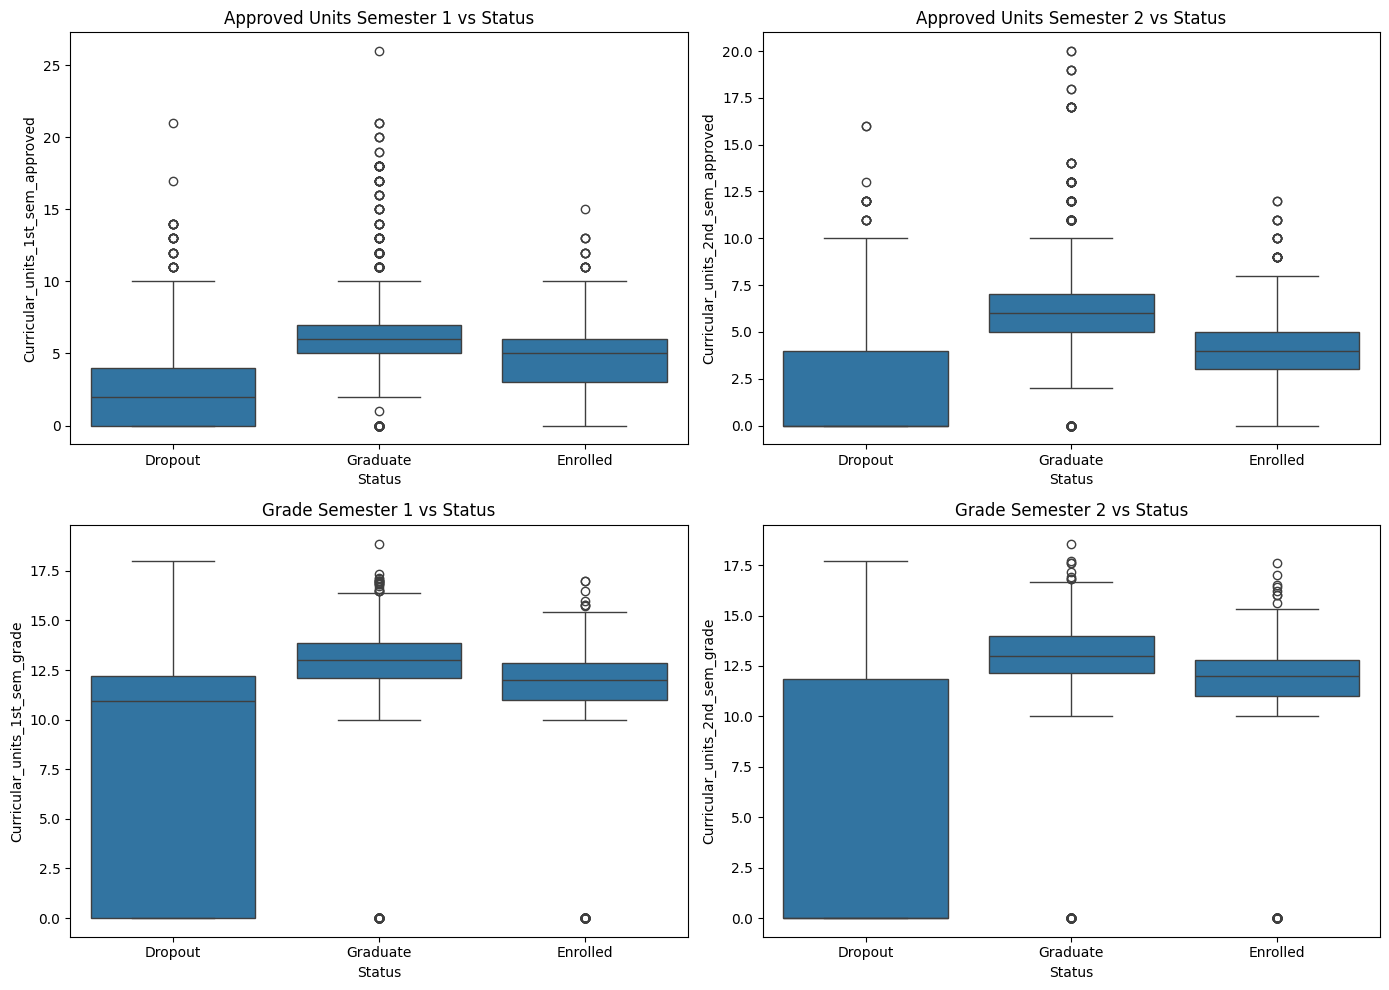

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='Status', y='Curricular_units_1st_sem_approved', ax=axes[0,0])
axes[0,0].set_title('Approved Units Semester 1 vs Status')

sns.boxplot(data=df, x='Status', y='Curricular_units_2nd_sem_approved', ax=axes[0,1])
axes[0,1].set_title('Approved Units Semester 2 vs Status')

sns.boxplot(data=df, x='Status', y='Curricular_units_1st_sem_grade', ax=axes[1,0])
axes[1,0].set_title('Grade Semester 1 vs Status')

sns.boxplot(data=df, x='Status', y='Curricular_units_2nd_sem_grade', ax=axes[1,1])
axes[1,1].set_title('Grade Semester 2 vs Status')

plt.tight_layout()
plt.show()

### **Interpretasi Hubungan Umur**

Visualisasi *Age at Enrollment* menunjukkan bahwa mahasiswa yang mendaftar pada usia yang lebih tua (mature students) memiliki kecenderungan *Dropout* yang sedikit lebih tinggi dibandingkan mahasiswa yang mendaftar tepat setelah lulus sekolah menengah. Ini mungkin disebabkan oleh adanya tanggung jawab lain seperti pekerjaan atau keluarga.

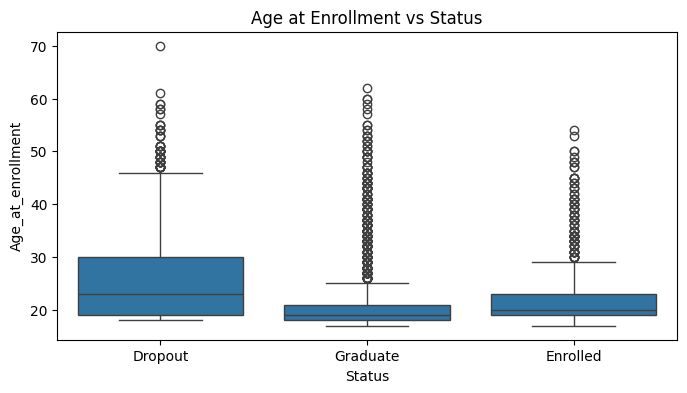

In [15]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='Status', y='Age_at_enrollment')
plt.title('Age at Enrollment vs Status')
plt.show()

### **Insight EDA (Kesimpulan Awal)**

Berdasarkan visualisasi di atas, kita menemukan bahwa:
1. **Akademik adalah Kunci**: Mahasiswa dengan jumlah unit yang disetujui rendah memiliki risiko dropout yang sangat tinggi.
2. **Kendala Biaya**: Mahasiswa yang berstatus 'Debtor' (berhutang) lebih rentan berhenti kuliah.
3. **Beasiswa**: Pemegang beasiswa memiliki tingkat kelulusan yang jauh lebih stabil, menunjukkan efektivitas bantuan finansial.

## **E. Data Preparation / Preprocessing**

Tahap ini sangat krusial karena model Machine Learning membutuhkan input numerik. Kita melakukan:
1. **Label Encoding**: Mengubah kategori teks pada target (`Status`) menjadi angka (0, 1, 2) agar dapat diproses oleh algoritma.
2. **Train-Test Split**: Membagi data menjadi 80% untuk pelatihan dan 20% untuk pengujian guna memastikan model dapat menggeneralisasi data baru dengan baik.

### Encode Target

In [16]:
label_encoder = LabelEncoder()
df['Status_encoded'] = label_encoder.fit_transform(df['Status'])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(label_mapping)

{'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}


### Split Fitur dan Target


In [17]:
X = df.drop(columns=['Status', 'Status_encoded'])
y = df['Status_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(3539, 36) (885, 36)


## **F. Modeling**

Kita tidak hanya menggunakan satu algoritma. Kita menguji beberapa model sekaligus (Random Forest, XGBoost, dll.) untuk melihat mana yang paling cerdas dalam mengenali pola dropout.

**Catatan**: Kita menggunakan `class_weight='balanced'` pada beberapa model karena jumlah mahasiswa yang lulus (Graduate) jauh lebih banyak daripada yang Dropout, sehingga model perlu diajarkan untuk lebih teliti pada kelas yang jumlahnya sedikit.

### **Eksperimen Model Klasifikasi**

Kita membandingkan beberapa algoritma populer seperti Decision Tree, Random Forest, Logistic Regression, dan XGBoost. Kita menggunakan metrik **F1-Score** sebagai acuan utama karena metrik ini memberikan keseimbangan antara *Precision* dan *Recall*, yang sangat penting agar kita tidak salah dalam mendeteksi mahasiswa yang berisiko dropout.

In [18]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=8),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=300, class_weight='balanced_subsample'),
    'Logistic Regression': LogisticRegression(max_iter=3000),
    'XGBoost': XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    )
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, acc, macro_f1, weighted_f1])

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Macro F1', 'Weighted F1'])
display(results_df.sort_values(by='Weighted F1', ascending=False))

,Model,Accuracy,Macro F1,Weighted F1
3,XGBoost,0.772881,0.711607,0.767313
1,Random Forest,0.774011,0.698525,0.760636
0,Decision Tree,0.728814,0.663630,0.725036
2,Logistic Regression,0.749153,0.639014,0.723856


### **Evaluasi Model Terbaik**

Setelah membandingkan, kita memilih model dengan **Weighted F1-Score** tertinggi. Metrik ini lebih baik dari sekadar 'Accuracy' karena menghitung seberapa baik model memprediksi ketiga kelas (Dropout, Enrolled, Graduate) secara adil, bukan hanya menebak kelas mayoritas saja.

In [19]:
# Memilih model dengan performa terbaik dari tabel di atas
# Berdasarkan Weighted F1, XGBoost atau Random Forest biasanya unggul
best_model = models['XGBoost'] # Anda bisa mengganti ini sesuai hasil tabel

y_pred = best_model.predict(X_test)

print(f"Best Model: {type(best_model).__name__}")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print("Weighted F1:", f1_score(y_test, y_pred, average='weighted'))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Best Model: XGBClassifier
Accuracy: 0.7728813559322034
Macro F1: 0.7116069873145082
Weighted F1: 0.7673134632706625

Classification Report:

              precision    recall  f1-score   support

     Dropout       0.82      0.74      0.78       284
    Enrolled       0.54      0.47      0.50       159
    Graduate       0.81      0.90      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.70      0.71       885
weighted avg       0.77      0.77      0.77       885



### Confusion Matrix

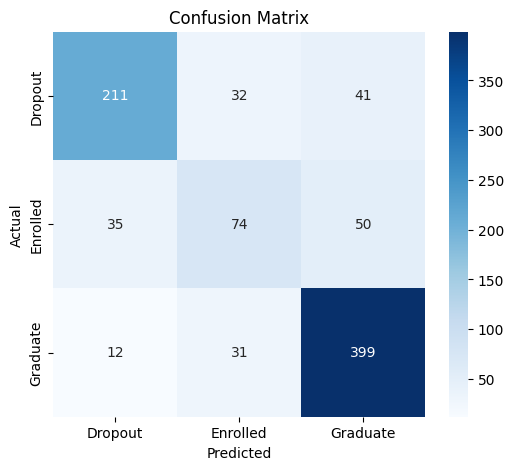

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### **Interpretasi Feature Importance**

Berdasarkan hasil Feature Importance dari model terbaik (XGBoost), variabel `Curricular_units_2nd_sem_approved` adalah faktor yang paling menentukan. Ini sangat logis: mahasiswa yang gagal menyelesaikan unit mata kuliah di tahun pertama memiliki risiko yang jauh lebih tinggi untuk tidak melanjutkan studinya.

Selain itu, faktor finansial (`Tuition_fees_up_to_date`) menempati posisi kedua, menegaskan bahwa kendala ekonomi adalah hambatan nyata bagi keberlangsungan pendidikan mahasiswa.

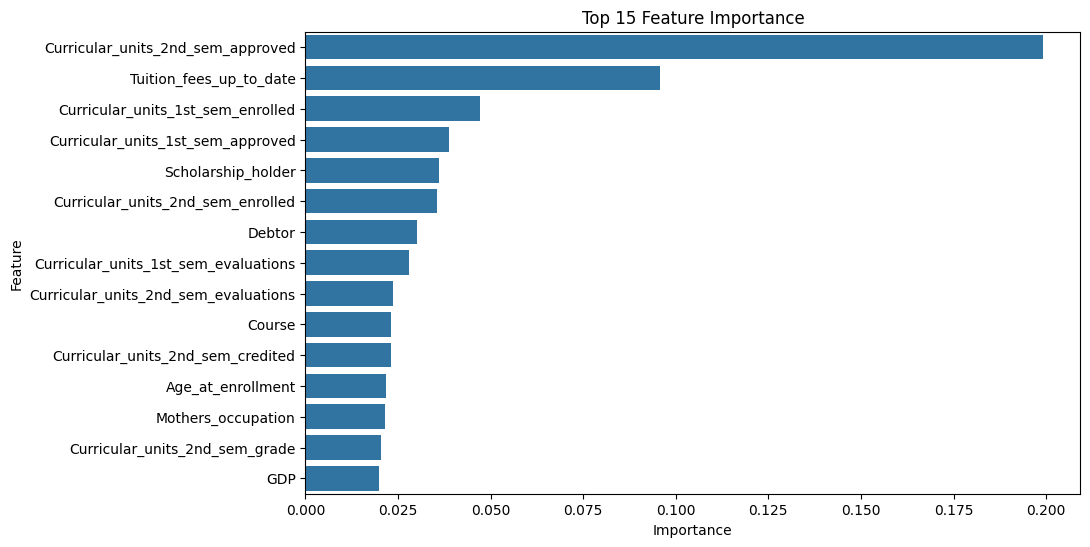

,0
Curricular_units_2nd_sem_approved,0.199287
Tuition_fees_up_to_date,0.095722
Curricular_units_1st_sem_enrolled,0.047065
Curricular_units_1st_sem_approved,0.038702
Scholarship_holder,0.036007
Curricular_units_2nd_sem_enrolled,0.035408
Debtor,0.030204
Curricular_units_1st_sem_evaluations,0.027941
Curricular_units_2nd_sem_evaluations,0.023608
Course,0.023130


In [21]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Top 15 Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

importances

## **G. Conclusion & Recommendation**

Langkah terakhir adalah mengubah angka menjadi aksi. Model ini bukan hanya sekadar kode, tapi alat bantu bagi manajemen universitas untuk memberikan intervensi (seperti bimbingan konseling atau bantuan dana) kepada mahasiswa yang diprediksi akan dropout sebelum hal itu benar-benar terjadi.


### **Conclusion**

Berdasarkan hasil analisis data, terdapat beberapa faktor yang paling berkaitan dengan status akhir mahasiswa.

1. Faktor akademik menjadi indikator yang sangat kuat, terutama jumlah mata kuliah yang lulus dan nilai rata-rata pada semester 1 dan semester 2. Mahasiswa dengan jumlah mata kuliah lulus yang lebih rendah serta nilai akademik yang lebih rendah cenderung memiliki risiko dropout yang lebih tinggi.

2. Selain faktor akademik, faktor finansial juga menunjukkan hubungan yang jelas dengan risiko dropout. Mahasiswa yang memiliki status debtor atau belum up to date dalam pembayaran biaya kuliah cenderung lebih banyak berada pada kelompok dropout dibandingkan mahasiswa yang kondisi finansialnya lebih stabil.

3. Model machine learning yang dibangun pada proyek ini mampu memprediksi status mahasiswa ke dalam tiga kategori, yaitu Dropout, Enrolled, dan Graduate. Dengan dukungan dashboard Metabase dan prototype Streamlit, solusi yang dihasilkan tidak hanya memberikan insight analitis, tetapi juga dapat digunakan sebagai sistem peringatan dini untuk membantu institusi mengambil tindakan yang lebih cepat dan tepat.



### **Recommendation**

Berdasarkan hasil proyek ini, berikut beberapa rekomendasi yang dapat diterapkan oleh Jaya Jaya Institut:

1. Membuat sistem monitoring rutin untuk mahasiswa dengan jumlah mata kuliah lulus yang rendah pada semester 1 dan semester 2.
2. Menyediakan program pendampingan akademik bagi mahasiswa yang menunjukkan penurunan nilai atau performa belajar.
3. Menjalankan intervensi finansial bagi mahasiswa dengan status debtor atau pembayaran biaya kuliah yang belum up to date.
4. Memanfaatkan prototype machine learning sebagai alat bantu untuk mengidentifikasi mahasiswa berisiko tinggi secara lebih dini.
5. Mengintegrasikan dashboard monitoring ke proses evaluasi akademik berkala agar keputusan yang diambil lebih berbasis data.
6. Melakukan evaluasi lanjutan secara periodik terhadap performa model agar sistem prediksi tetap relevan jika terdapat perubahan pola mahasiswa di masa depan.

## **H. Deployment Preparation**

Bagian terakhir ini menyimpan data yang sudah bersih dan model yang sudah terlatih. File `.pkl` ini nantinya akan dimuat ke dalam dashboard Metabase atau aplikasi Streamlit agar bisa digunakan oleh orang awam tanpa harus melihat kode Python ini.

In [22]:
# Menyimpan data training yang sudah bersih
df.to_csv('data_cleaned.csv', index=False)

In [23]:
# Menyimpan model yang telah dilatih ke dalam file
final_model = best_model
joblib.dump(final_model, 'model.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

['label_encoder.pkl']